# Week 5: Experimental Evaluation

This notebook evaluates the baseline attention implementation, embedded DSL execution, tiled attention transformation, and streaming tiled attention transformation developed during Weeks 1–4.

The experiments compare runtime performance, peak GPU memory usage, numerical correctness, scalability across sequence lengths, and the effect of tile size on execution behavior.

The outputs from this notebook will be used for the Results section, report figures, and experimental results tables in the final project report.

In [1]:
# Verify GPU availability in Google Colab

!nvidia-smi

Wed May 13 14:20:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import math
import time
import gc
import os
import platform
from dataclasses import dataclass

import torch
import pandas as pd
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Python version:", platform.python_version())
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch version: 2.10.0+cu128
Python version: 3.12.13
CUDA available: True
GPU: Tesla T4


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

os.makedirs("report_figures", exist_ok=True)
os.makedirs("report_tables", exist_ok=True)

print("Using device:", device)

Using device: cuda


In [4]:
def baseline_attention(q, k, v):
    """
    Standard scaled dot-product attention.

    This implementation materializes the full attention matrix:

        batch_size x num_heads x sequence_length x sequence_length

    This serves as the baseline reference implementation.
    """

    d_k = q.shape[-1]

    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    weights = torch.softmax(scores, dim=-1)

    output = torch.matmul(weights, v)

    return output

In [5]:
@dataclass
class AttentionSpec:
    """
    Lightweight Python-embedded DSL representation for attention execution.
    """

    name: str
    implementation: str
    tile_size: int = None

In [6]:
def tiled_attention(q, k, v, tile_size=128):
    """
    Tiled attention implementation.

    Attention is computed block-by-block across the query sequence.
    """

    batch_size, num_heads, seq_len, head_dim = q.shape

    outputs = []

    for start in range(0, seq_len, tile_size):

        end = min(start + tile_size, seq_len)

        q_block = q[:, :, start:end, :]

        scores = torch.matmul(
            q_block,
            k.transpose(-2, -1)
        ) / math.sqrt(head_dim)

        weights = torch.softmax(scores, dim=-1)

        out_block = torch.matmul(weights, v)

        outputs.append(out_block)

    return torch.cat(outputs, dim=2)

In [7]:
def streaming_tiled_attention(q, k, v, tile_size=128):
    """
    Streaming tiled attention implementation.

    Query blocks are processed incrementally and written into the output tensor.
    """

    batch_size, num_heads, seq_len, head_dim = q.shape

    output = torch.empty_like(q)

    for start in range(0, seq_len, tile_size):

        end = min(start + tile_size, seq_len)

        q_block = q[:, :, start:end, :]

        scores = torch.matmul(
            q_block,
            k.transpose(-2, -1)
        ) / math.sqrt(head_dim)

        weights = torch.softmax(scores, dim=-1)

        out_block = torch.matmul(weights, v)

        output[:, :, start:end, :] = out_block

        del q_block
        del scores
        del weights
        del out_block

    return output

In [8]:
def run_attention_from_spec(spec, q, k, v):
    """
    Executes attention using the implementation defined in the DSL specification.
    """

    if spec.implementation == "baseline":
        return baseline_attention(q, k, v)

    elif spec.implementation == "tiled":
        return tiled_attention(q, k, v, tile_size=spec.tile_size)

    elif spec.implementation == "streaming":
        return streaming_tiled_attention(q, k, v, tile_size=spec.tile_size)

    else:
        raise ValueError(f"Unknown implementation: {spec.implementation}")

In [9]:
def reset_memory():
    """
    Clears cached GPU memory before benchmarking.
    """

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

In [10]:
def get_peak_memory_mb():
    """
    Returns peak GPU memory usage in MB.
    """

    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)

    return None

In [11]:
def benchmark_function(func, q, k, v, warmup=2, trials=3):
    """
    Benchmarks runtime and memory usage for an attention implementation.
    """

    reset_memory()

    for _ in range(warmup):
        _ = func(q, k, v)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    reset_memory()

    start_time = time.perf_counter()

    for _ in range(trials):
        _ = func(q, k, v)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    end_time = time.perf_counter()

    avg_runtime_ms = ((end_time - start_time) / trials) * 1000

    peak_memory_mb = get_peak_memory_mb()

    return avg_runtime_ms, peak_memory_mb

In [12]:
def correctness_error(reference, candidate):
    """
    Computes maximum absolute difference between two tensors.
    """

    return torch.max(torch.abs(reference - candidate)).item()

In [13]:
sequence_lengths = [128, 256, 512, 1024]

batch_sizes = [1, 2]

num_heads = 4

head_dim = 64

tile_sizes = [64, 128, 256]

print("Experiment configuration loaded.")

Experiment configuration loaded.


In [14]:
results = []

for batch_size in batch_sizes:

    for seq_len in sequence_lengths:

        print(f"\nRunning experiments:")
        print(f"batch_size={batch_size}, seq_len={seq_len}")

        q = torch.randn(
            batch_size,
            num_heads,
            seq_len,
            head_dim,
            device=device
        )

        k = torch.randn(
            batch_size,
            num_heads,
            seq_len,
            head_dim,
            device=device
        )

        v = torch.randn(
            batch_size,
            num_heads,
            seq_len,
            head_dim,
            device=device
        )

        baseline_output = baseline_attention(q, k, v)

        runtime_ms, peak_memory_mb = benchmark_function(
            baseline_attention,
            q,
            k,
            v
        )

        results.append(
            {
                "implementation": "baseline",
                "batch_size": batch_size,
                "seq_len": seq_len,
                "tile_size": None,
                "runtime_ms": runtime_ms,
                "peak_memory_mb": peak_memory_mb,
                "max_abs_error": 0.0
            }
        )

        dsl_spec = AttentionSpec(
            name="dsl_baseline",
            implementation="baseline"
        )

        runtime_ms, peak_memory_mb = benchmark_function(
            lambda q, k, v: run_attention_from_spec(dsl_spec, q, k, v),
            q,
            k,
            v
        )

        dsl_output = run_attention_from_spec(dsl_spec, q, k, v)

        results.append(
            {
                "implementation": "dsl_baseline",
                "batch_size": batch_size,
                "seq_len": seq_len,
                "tile_size": None,
                "runtime_ms": runtime_ms,
                "peak_memory_mb": peak_memory_mb,
                "max_abs_error": correctness_error(baseline_output, dsl_output)
            }
        )

        for tile_size in tile_sizes:

            tiled_spec = AttentionSpec(
                name=f"tiled_{tile_size}",
                implementation="tiled",
                tile_size=tile_size
            )

            runtime_ms, peak_memory_mb = benchmark_function(
                lambda q, k, v, tile_size=tile_size: tiled_attention(
                    q,
                    k,
                    v,
                    tile_size=tile_size
                ),
                q,
                k,
                v
            )

            tiled_output = run_attention_from_spec(tiled_spec, q, k, v)

            results.append(
                {
                    "implementation": "tiled",
                    "batch_size": batch_size,
                    "seq_len": seq_len,
                    "tile_size": tile_size,
                    "runtime_ms": runtime_ms,
                    "peak_memory_mb": peak_memory_mb,
                    "max_abs_error": correctness_error(
                        baseline_output,
                        tiled_output
                    )
                }
            )

            streaming_spec = AttentionSpec(
                name=f"streaming_{tile_size}",
                implementation="streaming",
                tile_size=tile_size
            )

            runtime_ms, peak_memory_mb = benchmark_function(
                lambda q, k, v, tile_size=tile_size: streaming_tiled_attention(
                    q,
                    k,
                    v,
                    tile_size=tile_size
                ),
                q,
                k,
                v
            )

            streaming_output = run_attention_from_spec(
                streaming_spec,
                q,
                k,
                v
            )

            results.append(
                {
                    "implementation": "streaming",
                    "batch_size": batch_size,
                    "seq_len": seq_len,
                    "tile_size": tile_size,
                    "runtime_ms": runtime_ms,
                    "peak_memory_mb": peak_memory_mb,
                    "max_abs_error": correctness_error(
                        baseline_output,
                        streaming_output
                    )
                }
            )

        del q
        del k
        del v
        del baseline_output

        reset_memory()

print("\nExperiments complete.")


Running experiments:
batch_size=1, seq_len=128

Running experiments:
batch_size=1, seq_len=256

Running experiments:
batch_size=1, seq_len=512

Running experiments:
batch_size=1, seq_len=1024

Running experiments:
batch_size=2, seq_len=128

Running experiments:
batch_size=2, seq_len=256

Running experiments:
batch_size=2, seq_len=512

Running experiments:
batch_size=2, seq_len=1024

Experiments complete.


In [15]:
results_df = pd.DataFrame(results)

results_df.head()

,implementation,batch_size,seq_len,tile_size,runtime_ms,peak_memory_mb,max_abs_error
0,baseline,1,128,NaN,0.175711,9.2500,0.0
1,dsl_baseline,1,128,NaN,0.178399,9.2500,0.0
2,tiled,1,128,64.0,0.346229,9.3125,0.0
3,streaming,1,128,64.0,0.569511,9.3125,0.0
4,tiled,1,128,128.0,0.246769,9.7500,0.0


In [16]:
plot_results_df = results_df.copy()

plot_results_df["tile_label"] = plot_results_df["tile_size"].apply(
    lambda x: "none" if pd.isna(x) else f"tile={int(x)}"
)

plot_results_df["plot_label"] = plot_results_df.apply(
    lambda row: row["implementation"]
    if row["tile_label"] == "none"
    else f"{row['implementation']}, {row['tile_label']}",
    axis=1
)

plot_results_df.head()

,implementation,batch_size,seq_len,tile_size,runtime_ms,peak_memory_mb,max_abs_error,tile_label,plot_label
0,baseline,1,128,NaN,0.175711,9.2500,0.0,none,baseline
1,dsl_baseline,1,128,NaN,0.178399,9.2500,0.0,none,dsl_baseline
2,tiled,1,128,64.0,0.346229,9.3125,0.0,tile=64,"tiled, tile=64"
3,streaming,1,128,64.0,0.569511,9.3125,0.0,tile=64,"streaming, tile=64"
4,tiled,1,128,128.0,0.246769,9.7500,0.0,tile=128,"tiled, tile=128"


In [17]:
runtime_table = plot_results_df.pivot_table(
    index=["batch_size", "seq_len"],
    columns="plot_label",
    values="runtime_ms"
)

runtime_table

plot_label          baseline  dsl_baseline  streaming, tile=128  \
batch_size seq_len                                                
1          128      0.175711      0.178399             0.275217   
           256      0.276831      0.534992             0.354856   
           512      0.382689      0.612878             0.795938   
           1024     1.189107      1.186910             2.142589   
2          128      0.178565      0.357202             0.247391   
           256      0.252616      0.437862             0.455682   
           512      0.641045      0.691219             1.031200   
           1024     1.803124      1.802167             3.489884   

plot_label          streaming, tile=256  streaming, tile=64  tiled, tile=128  \
batch_size seq_len                                                             
1          128                 0.268282            0.569511         0.246769   
           256                 0.410875            0.581345         0.326371   
           512                 0.534491            1.071330         0.811010   
           1024                1.752182            3.568230         2.120819   
2          128                 0.236993            0.339807         0.238107   
           256                 0.350772            0.646507         0.437791   
           512                 0.801229            2.155903         1.226049   
           1024                2.420971            5.653193         3.532696   

plot_label          tiled, tile=256  tiled, tile=64  
batch_size seq_len                                   
1          128             0.248736        0.346229  
           256             0.323500        0.515411  
           512             0.525348        1.505484  
           1024            1.747611        3.587464  
2          128             0.244349        0.318947  
           256             0.270225        0.665828  
           512             0.741977        1.778709  
           1024            2.386803        5.544240

In [18]:
memory_table = plot_results_df.pivot_table(
    index=["batch_size", "seq_len"],
    columns="plot_label",
    values="peak_memory_mb"
)

memory_table

plot_label          baseline  dsl_baseline  streaming, tile=128  \
batch_size seq_len                                                
1          128         9.250         9.250                9.750   
           256        11.750        11.750               11.250   
           512        19.375        19.375               14.250   
           1024       46.625        46.625               20.250   
2          128        13.375        13.375               11.375   
           256        15.375        15.375               14.375   
           512        30.625        30.625               20.375   
           1024       85.125        85.125               32.375   

plot_label          streaming, tile=256  streaming, tile=64  tiled, tile=128  \
batch_size seq_len                                                             
1          128                    9.750              9.3125            9.750   
           256                   12.375             10.5625           12.000   
           512                   16.375             12.9375           16.000   
           1024                  24.375             17.6875           24.000   
2          128                   11.375             11.5000           11.375   
           256                   16.625             13.0000           15.875   
           512                   24.625             17.7500           23.875   
           1024                  40.625             27.2500           39.875   

plot_label          tiled, tile=256  tiled, tile=64  
batch_size seq_len                                   
1          128                9.750          9.3125  
           256               12.375         10.8125  
           512               19.875         13.5625  
           1024              31.875         19.0625  
2          128               11.375         12.5000  
           256               16.625         13.5000  
           512               31.625         19.0000  
           1024              55.625         30.0000

In [19]:
correctness_table = plot_results_df[
    [
        "implementation",
        "batch_size",
        "seq_len",
        "tile_size",
        "max_abs_error"
    ]
]

correctness_table

,implementation,batch_size,seq_len,tile_size,max_abs_error
0,baseline,1,128,NaN,0.0
1,dsl_baseline,1,128,NaN,0.0
2,tiled,1,128,64.0,0.0
3,streaming,1,128,64.0,0.0
4,tiled,1,128,128.0,0.0
...,...,...,...,...,...
59,streaming,2,1024,64.0,0.0
60,tiled,2,1024,128.0,0.0
61,streaming,2,1024,128.0,0.0
62,tiled,2,1024,256.0,0.0


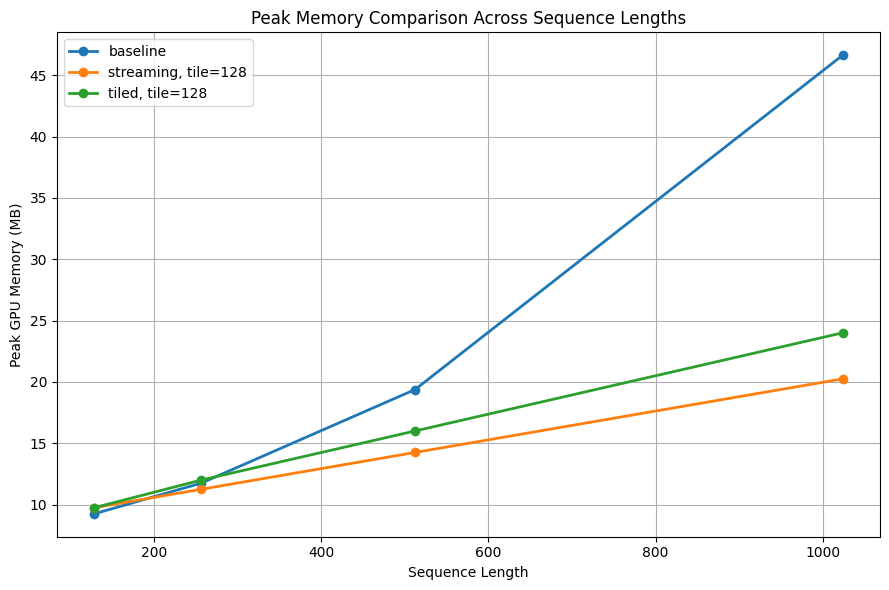

In [20]:
figure1_df = plot_results_df[
    (
        (plot_results_df["implementation"] == "baseline")
        |
        (
            (plot_results_df["implementation"] == "tiled")
            &
            (plot_results_df["tile_size"] == 128)
        )
        |
        (
            (plot_results_df["implementation"] == "streaming")
            &
            (plot_results_df["tile_size"] == 128)
        )
    )
    &
    (plot_results_df["batch_size"] == 1)
]

if figure1_df["peak_memory_mb"].notna().any():

    plt.figure(figsize=(9, 6))

    for label, group in figure1_df.groupby("plot_label"):

        group = group.sort_values("seq_len")

        plt.plot(
            group["seq_len"],
            group["peak_memory_mb"],
            marker="o",
            linewidth=2,
            label=label
        )

    plt.xlabel("Sequence Length")
    plt.ylabel("Peak GPU Memory (MB)")
    plt.title("Peak Memory Comparison Across Sequence Lengths")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        "report_figures/figure1_peak_memory_comparison.png",
        dpi=300
    )

    plt.show()

else:
    print("GPU memory measurements unavailable.")

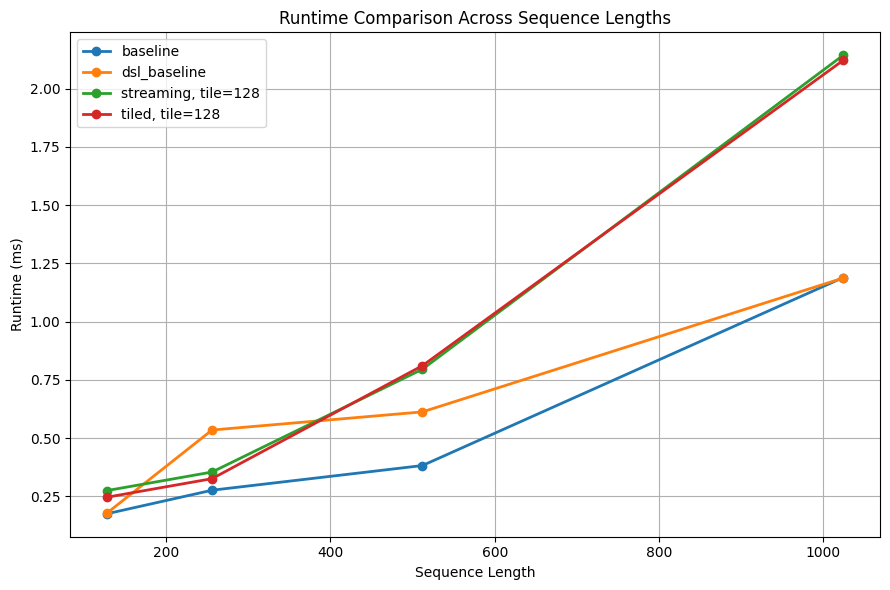

In [21]:
figure2_df = plot_results_df[
    (
        (plot_results_df["implementation"] == "baseline")
        |
        (plot_results_df["implementation"] == "dsl_baseline")
        |
        (
            (plot_results_df["implementation"] == "tiled")
            &
            (plot_results_df["tile_size"] == 128)
        )
        |
        (
            (plot_results_df["implementation"] == "streaming")
            &
            (plot_results_df["tile_size"] == 128)
        )
    )
    &
    (plot_results_df["batch_size"] == 1)
]

plt.figure(figsize=(9, 6))

for label, group in figure2_df.groupby("plot_label"):

    group = group.sort_values("seq_len")

    plt.plot(
        group["seq_len"],
        group["runtime_ms"],
        marker="o",
        linewidth=2,
        label=label
    )

plt.xlabel("Sequence Length")
plt.ylabel("Runtime (ms)")
plt.title("Runtime Comparison Across Sequence Lengths")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "report_figures/figure2_runtime_comparison.png",
    dpi=300
)

plt.show()

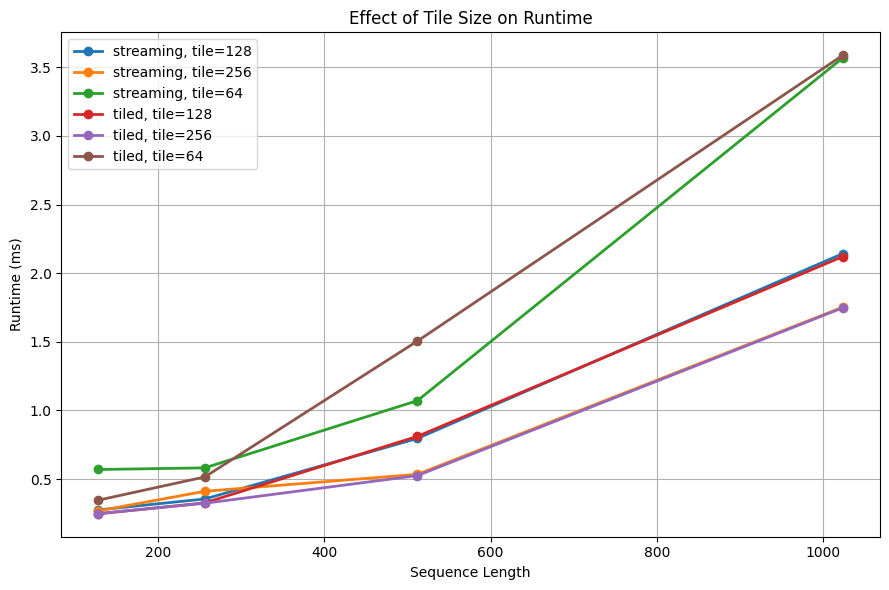

In [22]:
figure3_df = plot_results_df[
    (
        (plot_results_df["implementation"] == "tiled")
        |
        (plot_results_df["implementation"] == "streaming")
    )
    &
    (plot_results_df["batch_size"] == 1)
]

plt.figure(figsize=(9, 6))

for label, group in figure3_df.groupby("plot_label"):

    group = group.sort_values("seq_len")

    plt.plot(
        group["seq_len"],
        group["runtime_ms"],
        marker="o",
        linewidth=2,
        label=label
    )

plt.xlabel("Sequence Length")
plt.ylabel("Runtime (ms)")
plt.title("Effect of Tile Size on Runtime")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "report_figures/figure3_tile_size_runtime.png",
    dpi=300
)

plt.show()

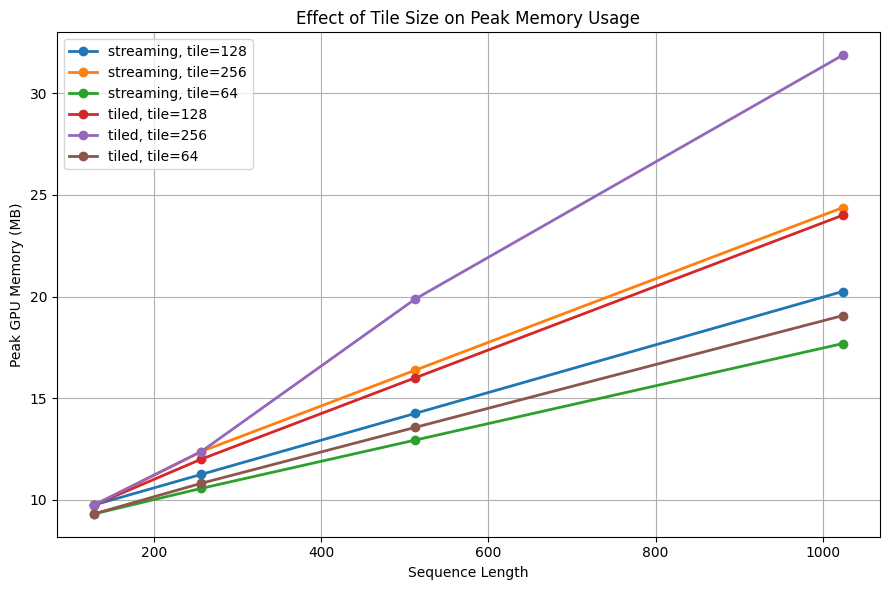

In [23]:
figure4_df = plot_results_df[
    (
        (plot_results_df["implementation"] == "tiled")
        |
        (plot_results_df["implementation"] == "streaming")
    )
    &
    (plot_results_df["batch_size"] == 1)
]

if figure4_df["peak_memory_mb"].notna().any():

    plt.figure(figsize=(9, 6))

    for label, group in figure4_df.groupby("plot_label"):

        group = group.sort_values("seq_len")

        plt.plot(
            group["seq_len"],
            group["peak_memory_mb"],
            marker="o",
            linewidth=2,
            label=label
        )

    plt.xlabel("Sequence Length")
    plt.ylabel("Peak GPU Memory (MB)")
    plt.title("Effect of Tile Size on Peak Memory Usage")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.savefig(
        "report_figures/figure4_tile_size_memory.png",
        dpi=300
    )

    plt.show()

else:
    print("GPU memory measurements unavailable.")

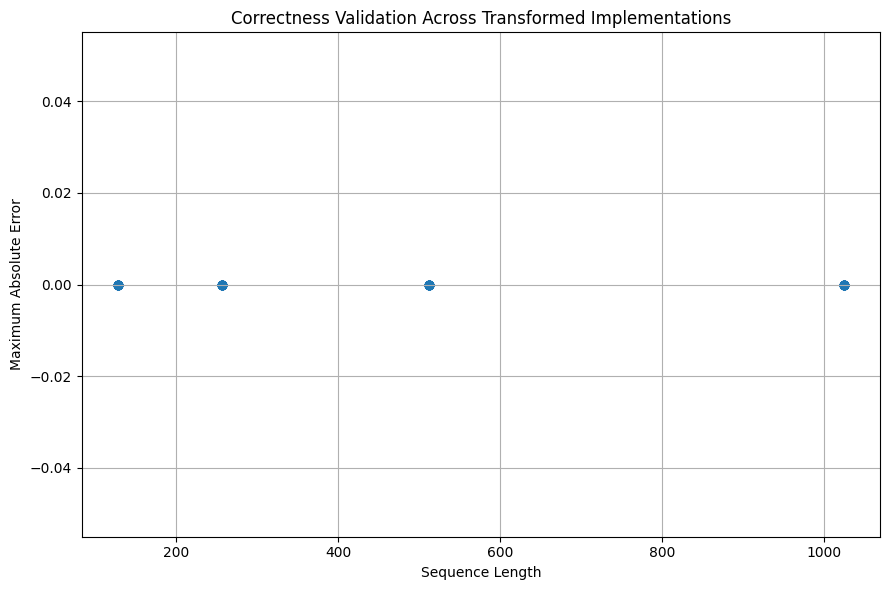

In [24]:
figure5_df = plot_results_df[
    plot_results_df["implementation"] != "baseline"
]

plt.figure(figsize=(9, 6))

plt.scatter(
    figure5_df["seq_len"],
    figure5_df["max_abs_error"]
)

plt.xlabel("Sequence Length")
plt.ylabel("Maximum Absolute Error")
plt.title("Correctness Validation Across Transformed Implementations")
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "report_figures/figure5_correctness_validation.png",
    dpi=300
)

plt.show()

In [25]:
table1_runtime = plot_results_df[
    (
        (plot_results_df["implementation"] == "baseline")
        |
        (plot_results_df["implementation"] == "dsl_baseline")
        |
        (
            (plot_results_df["implementation"] == "tiled")
            &
            (plot_results_df["tile_size"] == 128)
        )
        |
        (
            (plot_results_df["implementation"] == "streaming")
            &
            (plot_results_df["tile_size"] == 128)
        )
    )
    &
    (plot_results_df["batch_size"] == 1)
].pivot_table(
    index="seq_len",
    columns="plot_label",
    values="runtime_ms"
).reset_index()

table1_runtime.to_csv(
    "report_tables/table1_runtime_comparison.csv",
    index=False
)

table1_runtime

plot_label,seq_len,baseline,dsl_baseline,"streaming, tile=128","tiled, tile=128"
0,128,0.175711,0.178399,0.275217,0.246769
1,256,0.276831,0.534992,0.354856,0.326371
2,512,0.382689,0.612878,0.795938,0.811010
3,1024,1.189107,1.186910,2.142589,2.120819


In [26]:
table2_memory = plot_results_df[
    (
        (plot_results_df["implementation"] == "baseline")
        |
        (
            (plot_results_df["implementation"] == "tiled")
            &
            (plot_results_df["tile_size"] == 128)
        )
        |
        (
            (plot_results_df["implementation"] == "streaming")
            &
            (plot_results_df["tile_size"] == 128)
        )
    )
    &
    (plot_results_df["batch_size"] == 1)
].pivot_table(
    index="seq_len",
    columns="plot_label",
    values="peak_memory_mb"
).reset_index()

table2_memory.to_csv(
    "report_tables/table2_peak_memory_comparison.csv",
    index=False
)

table2_memory

plot_label,seq_len,baseline,"streaming, tile=128","tiled, tile=128"
0,128,9.250,9.75,9.75
1,256,11.750,11.25,12.00
2,512,19.375,14.25,16.00
3,1024,46.625,20.25,24.00


In [27]:
summary_df = results_df.groupby(
    "implementation"
).agg(
    avg_runtime_ms=("runtime_ms", "mean"),
    max_runtime_ms=("runtime_ms", "max"),
    avg_peak_memory_mb=("peak_memory_mb", "mean"),
    max_peak_memory_mb=("peak_memory_mb", "max"),
    max_correctness_error=("max_abs_error", "max")
).reset_index()

summary_df.to_csv(
    "report_tables/table3_implementation_summary.csv",
    index=False
)

summary_df

,implementation,avg_runtime_ms,max_runtime_ms,avg_peak_memory_mb,max_peak_memory_mb,max_correctness_error
0,baseline,0.612461,1.803124,28.937500,85.125,0.0
1,dsl_baseline,0.725204,1.802167,28.937500,85.125,0.0
2,streaming,1.256432,5.653193,17.088542,40.625,0.0
3,tiled,1.237103,5.544240,19.567708,55.625,0.0


In [28]:
results_df.to_csv(
    "week5_attention_results.csv",
    index=False
)

summary_df.to_csv(
    "week5_attention_summary.csv",
    index=False
)

print("Saved CSV files:")
print("week5_attention_results.csv")
print("week5_attention_summary.csv")
print("report_tables/table1_runtime_comparison.csv")
print("report_tables/table2_peak_memory_comparison.csv")
print("report_tables/table3_implementation_summary.csv")

Saved CSV files:
week5_attention_results.csv
week5_attention_summary.csv
report_tables/table1_runtime_comparison.csv
report_tables/table2_peak_memory_comparison.csv
report_tables/table3_implementation_summary.csv


In [29]:
from google.colab import files

files.download("week5_attention_results.csv")
files.download("week5_attention_summary.csv")

files.download("report_tables/table1_runtime_comparison.csv")
files.download("report_tables/table2_peak_memory_comparison.csv")
files.download("report_tables/table3_implementation_summary.csv")

files.download("report_figures/figure1_peak_memory_comparison.png")
files.download("report_figures/figure2_runtime_comparison.png")
files.download("report_figures/figure3_tile_size_runtime.png")
files.download("report_figures/figure4_tile_size_memory.png")
files.download("report_figures/figure5_correctness_validation.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Week 5 Summary

This notebook evaluated multiple attention execution strategies developed during Weeks 1–4 of the project:

1. Baseline scaled dot-product attention  
2. DSL baseline execution  
3. Tiled attention transformation  
4. Streaming tiled attention transformation  

The experiments measured runtime performance, peak GPU memory usage, numerical correctness, scalability across sequence lengths, and the effect of tile size on execution behavior.

The revised figures and tables generated in this notebook are designed for direct use in the final project report. In particular, Figure 1 now includes the baseline implementation, tiled execution, and streaming execution, which makes the memory reduction comparison clearer and better aligned with the Results section of the report.

The tiled and streaming implementations preserved exact attention semantics while reducing intermediate memory pressure through block-wise execution patterns. Although the current prototype uses high-level PyTorch tensor operations rather than custom CUDA kernels, the results demonstrate that compiler-style transformations can expose memory-efficient execution strategies through a programmable, domain-specific abstraction.